# **Preparación y análisis de datos**

Este cuaderno contiene la preparación y análisis exploratorio de los datos


## **1. Importación de librerías y configuración de gráficas**

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Configuramos las librerías de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = [10, 6]

## **2. Carga de Datos**

In [31]:
# Cargamos el corpus de razas de perros
df = pd.read_csv('data/akc-data-latest.csv')

# Mostramos información básica del dataset
print(f"Dimensiones del dataset: {df.shape}")
print(f"Número de razas: {len(df)}")
print(f"Columnas disponibles: {len(df.columns)}")

# Mostramso primeras filas
df.head()

Dimensiones del dataset: (277, 21)
Número de razas: 277
Columnas disponibles: 21


,breed,description,temperament,popularity,min_height,max_height,min_weight,max_weight,min_expectancy,max_expectancy,...,grooming_frequency_value,grooming_frequency_category,shedding_value,shedding_category,energy_level_value,energy_level_category,trainability_value,trainability_category,demeanor_value,demeanor_category
0,Affenpinscher,The Affen’s apish look has been described many...,"Confident, Famously Funny, Fearless",148,22.86,29.21,3.175147,4.535924,12.0,15.0,...,0.6,2-3 Times a Week Brushing,0.6,Seasonal,0.6,Regular Exercise,0.8,Easy Training,1.0,Outgoing
1,Afghan Hound,"The Afghan Hound is an ancient breed, his whol...","Dignified, Profoundly Loyal, Aristocratic",113,63.50,68.58,22.679619,27.215542,12.0,15.0,...,0.8,Daily Brushing,0.2,Infrequent,0.8,Energetic,0.2,May be Stubborn,0.2,Aloof/Wary
2,Airedale Terrier,The Airedale Terrier is the largest of all ter...,"Friendly, Clever, Courageous",60,58.42,58.42,22.679619,31.751466,11.0,14.0,...,0.6,2-3 Times a Week Brushing,0.4,Occasional,0.6,Regular Exercise,1.0,Eager to Please,0.8,Friendly
3,Akita,"Akitas are burly, heavy-boned spitz-type dogs ...","Courageous, Dignified, Profoundly Loyal",47,60.96,71.12,31.751466,58.967008,10.0,13.0,...,0.8,Daily Brushing,0.6,Seasonal,0.8,Energetic,1.0,Eager to Please,0.6,Alert/Responsive
4,Alaskan Malamute,The Alaskan Malamute stands 23 to 25 inches at...,"Affectionate, Loyal, Playful",58,58.42,63.50,34.019428,38.555351,10.0,14.0,...,0.6,2-3 Times a Week Brushing,0.6,Seasonal,0.8,Energetic,0.4,Independent,0.8,Friendly


## **3. Exploración de datos**

In [32]:
# Mostramos información del corpus, columnas, tipos de datos y valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   breed                        277 non-null    object 
 1   description                  277 non-null    object 
 2   temperament                  276 non-null    object 
 3   popularity                   198 non-null    object 
 4   min_height                   277 non-null    float64
 5   max_height                   277 non-null    float64
 6   min_weight                   275 non-null    float64
 7   max_weight                   275 non-null    float64
 8   min_expectancy               274 non-null    float64
 9   max_expectancy               274 non-null    float64
 10  group                        277 non-null    object 
 11  grooming_frequency_value     270 non-null    float64
 12  grooming_frequency_category  270 non-null    object 
 13  shedding_value      

In [33]:
# Mostramos estadísticas descriptivas, incluyendo conteo, media, desviación estándar, mínimo, percentiles y máximo
df.describe().T

,count,mean,std,min,25%,50%,75%,max
min_height,277.0,44.225801,14.238298,12.70,33.020000,45.085000,55.880000,76.200000
max_height,277.0,52.720588,15.885454,17.78,38.100000,53.340000,66.040000,88.900000
min_weight,275.0,17.888858,12.290600,0.00,8.164663,15.875733,22.679619,68.038855
max_weight,275.0,27.291416,19.061416,0.00,12.927383,24.947580,34.019428,108.862169
min_expectancy,274.0,11.306569,1.817949,0.00,10.000000,12.000000,12.000000,16.000000
max_expectancy,274.0,13.832117,2.016668,0.00,13.000000,14.000000,15.000000,19.000000
grooming_frequency_value,270.0,0.425926,0.198306,0.20,0.200000,0.400000,0.600000,1.000000
shedding_value,257.0,0.529183,0.189068,0.20,0.400000,0.600000,0.600000,1.000000
energy_level_value,271.0,0.712915,0.168927,0.20,0.600000,0.600000,0.800000,1.000000
trainability_value,253.0,0.624506,0.247271,0.20,0.400000,0.600000,0.800000,1.000000


In [34]:
# Mostramos valores faltantes en el dataset
missing_values = df.isnull().sum()
# Calculamos el porcentaje de valores faltantes
missing_percent = (missing_values / len(df)) * 100
# Creamos un DataFrame con los valores faltantes y su porcentaje
# y lo ordenamos de mayor a menor y filtramos para mostrar solo las columnas con valores faltantes
missing_df = pd.DataFrame({'Valores faltantes': missing_values, 'Porcentaje': missing_percent})
missing_df = missing_df[missing_df['Valores faltantes'] > 0].sort_values('Valores faltantes', ascending=False)

print("Columnas con valores faltantes:")
if len(missing_df) > 0:
    display(missing_df)
else:
    print("No hay valores faltantes en el dataset.")

Columnas con valores faltantes:


,Valores faltantes,Porcentaje
popularity,79,28.519856
demeanor_value,25,9.025271
demeanor_category,25,9.025271
trainability_value,24,8.664260
trainability_category,24,8.664260
shedding_value,20,7.220217
shedding_category,20,7.220217
grooming_frequency_value,7,2.527076
grooming_frequency_category,7,2.527076
energy_level_value,6,2.166065


## **4. Análisis de variables categóricas**

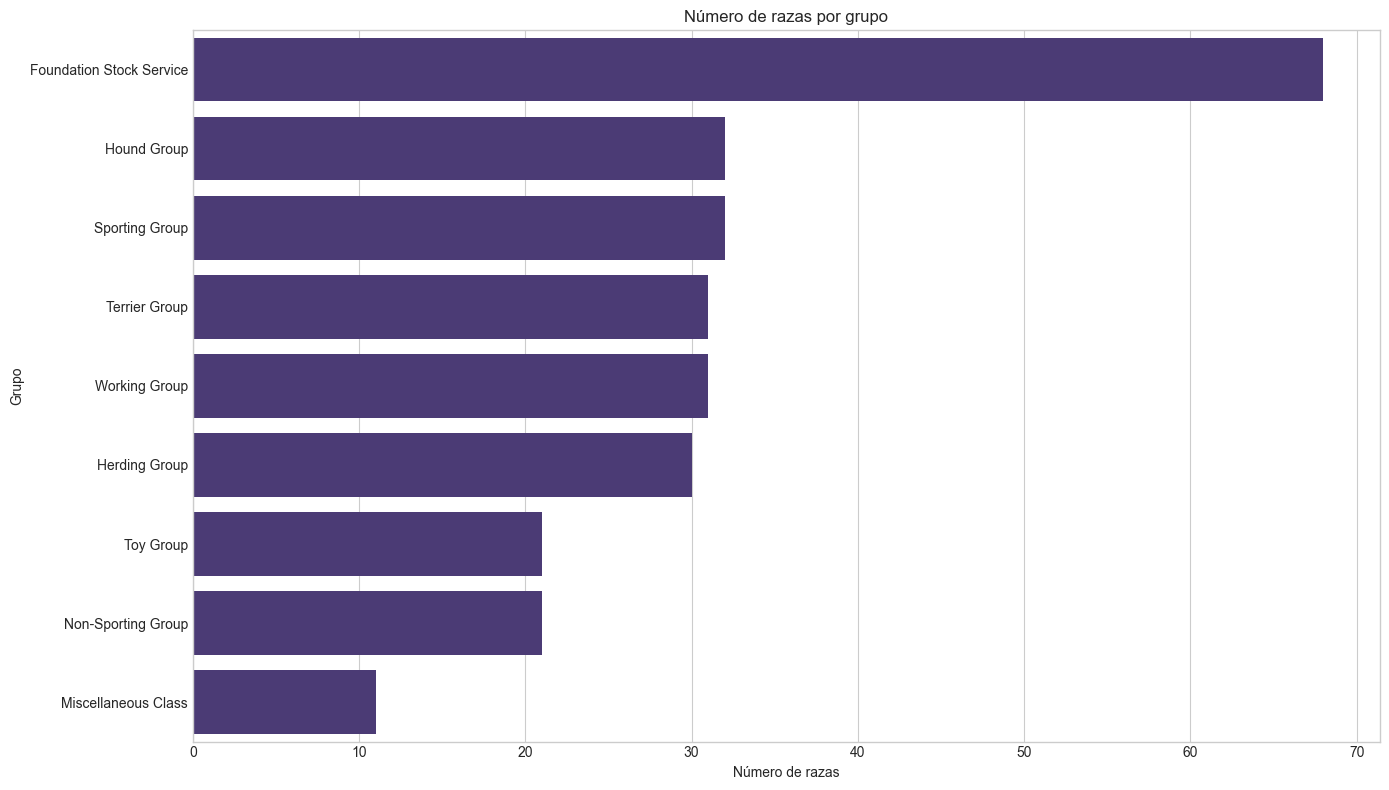

In [35]:
# Mostramos la distribución de grupos de razas
plt.figure(figsize=(14, 8))
group_counts = df['group'].value_counts()
sns.barplot(x=group_counts.values, y=group_counts.index)
plt.title('Número de razas por grupo')
plt.xlabel('Número de razas')
plt.ylabel('Grupo')
plt.tight_layout()
plt.show()

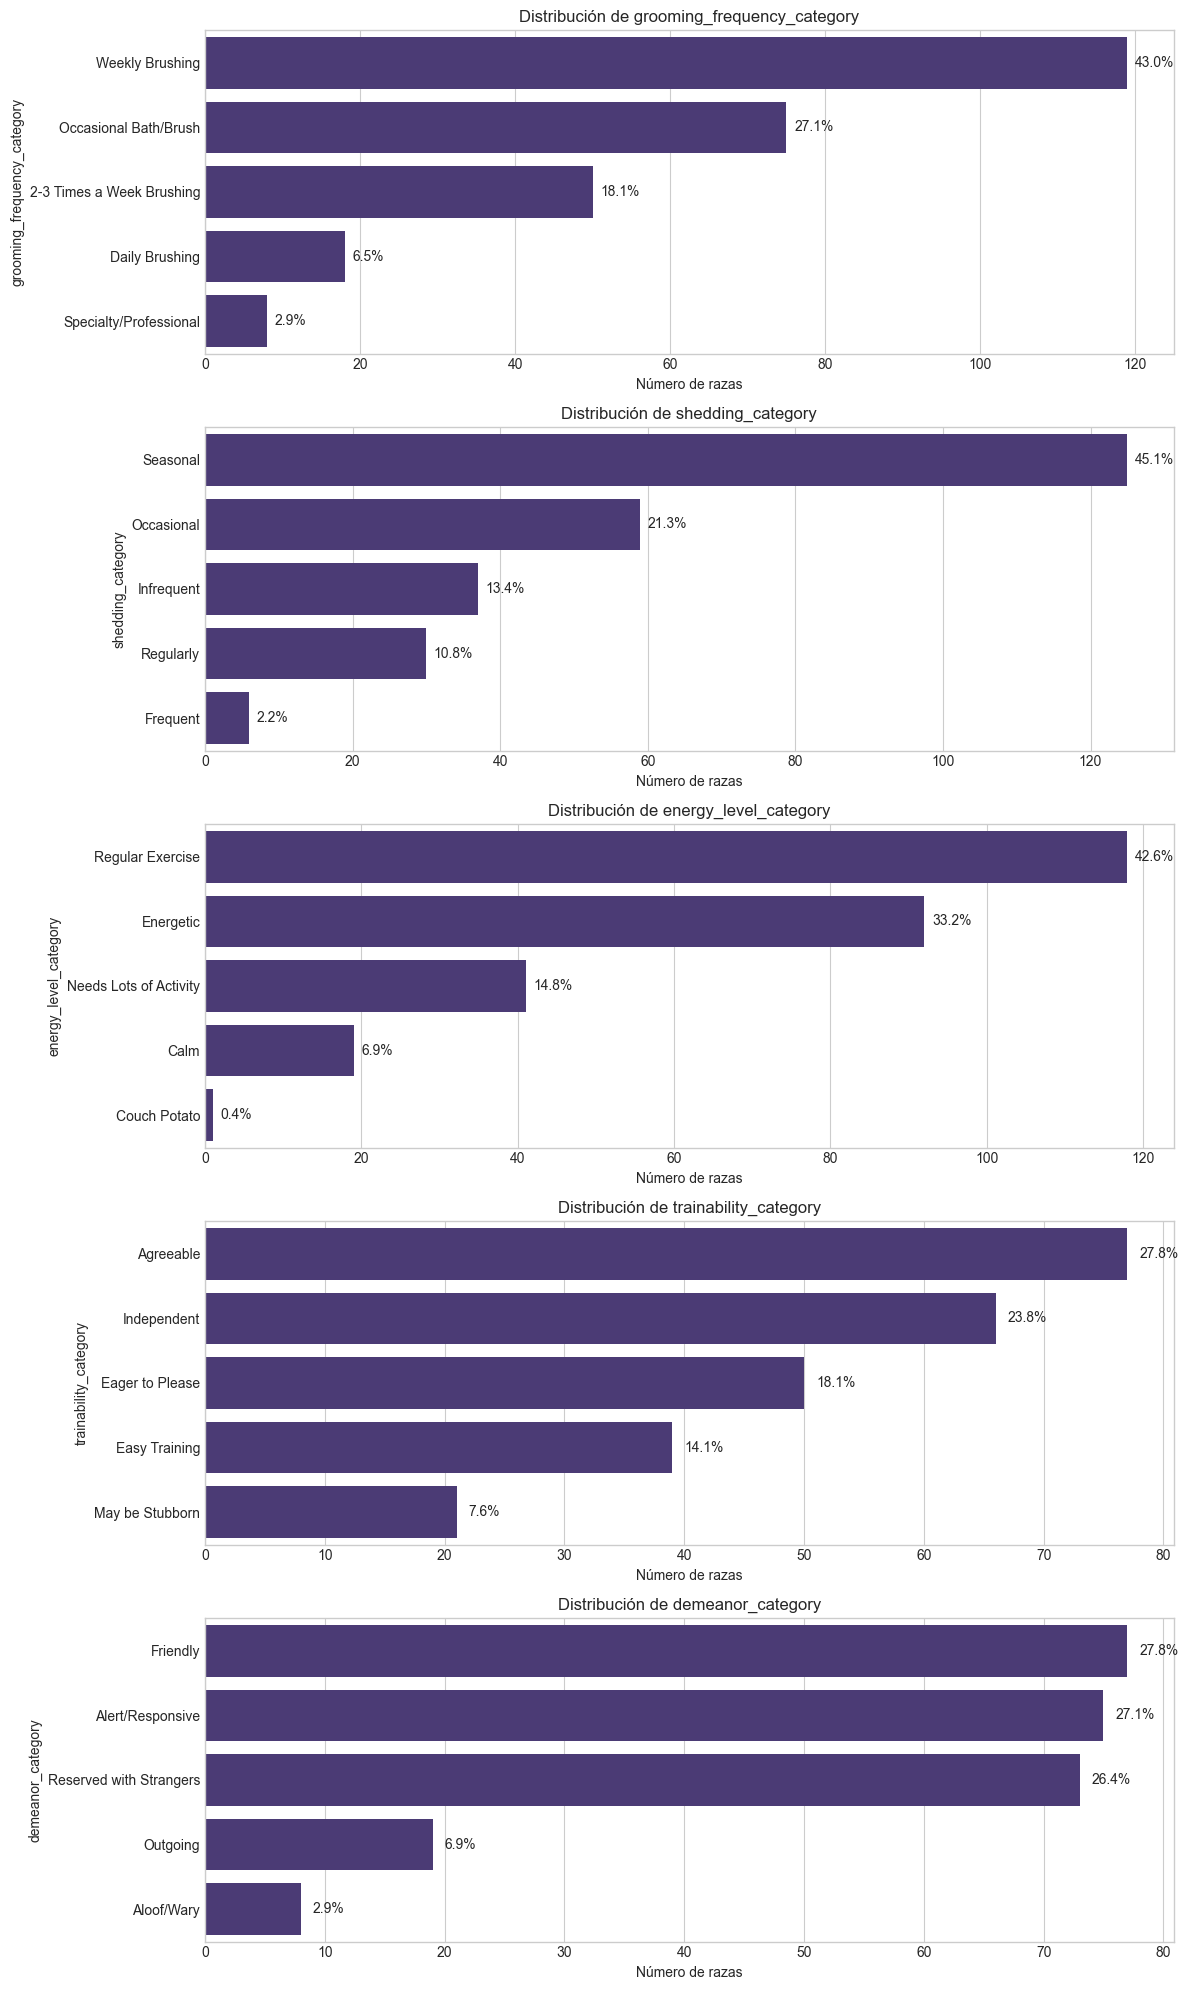

In [36]:
# Obtenemos la distribución por categoría
categorical_cols = [
    "grooming_frequency_category",
    "shedding_category",
    "energy_level_category",
    "trainability_category",
    "demeanor_category"
]

fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(12, 20))

for i, col in enumerate(categorical_cols):
    sns.countplot(y=df[col], ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel('Número de razas')
    # Añadimos etiquetas de porcentaje
    total = len(df)
    for j, p in enumerate(axes[i].patches):
        width = p.get_width()
        axes[i].text(width + 1, p.get_y() + p.get_height()/2, 
                f'{width/total:.1%}', 
                ha='left', va='center')

plt.tight_layout()
plt.show()

## **5. Análisis de variables numéricas**

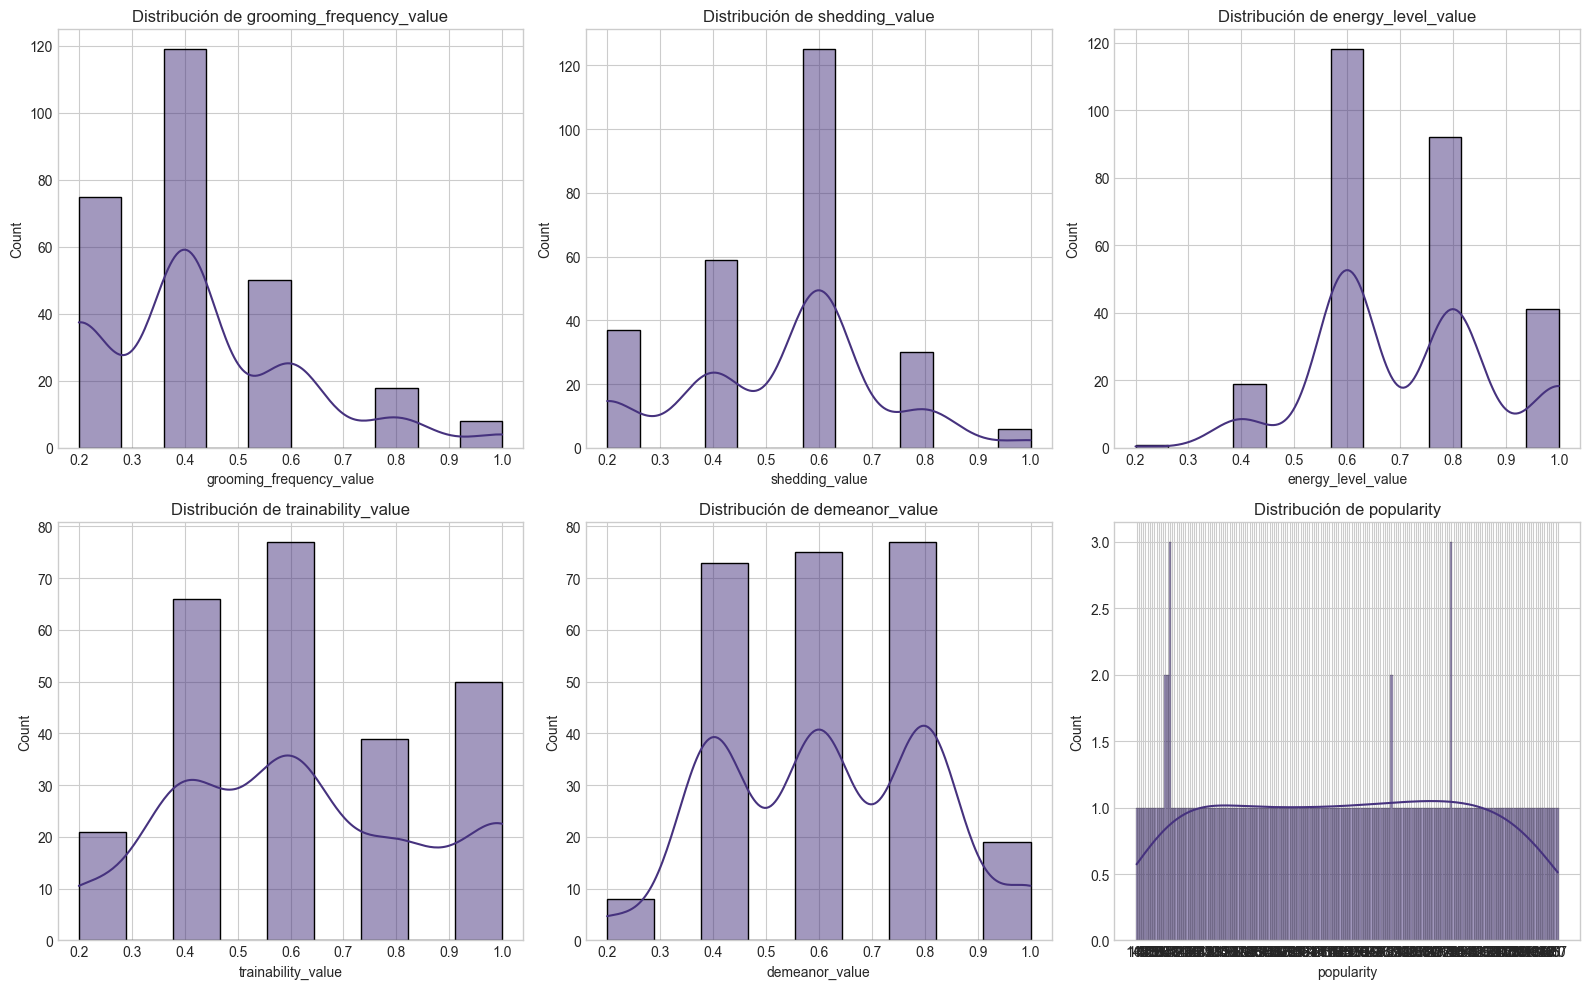

In [37]:
# Mostamos la distribución de variables ordinales
numerical_cols = [
    "grooming_frequency_value",
    "shedding_value",
    "energy_level_value",
    "trainability_value",
    "demeanor_value",
    "popularity"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    
plt.tight_layout()
plt.show()

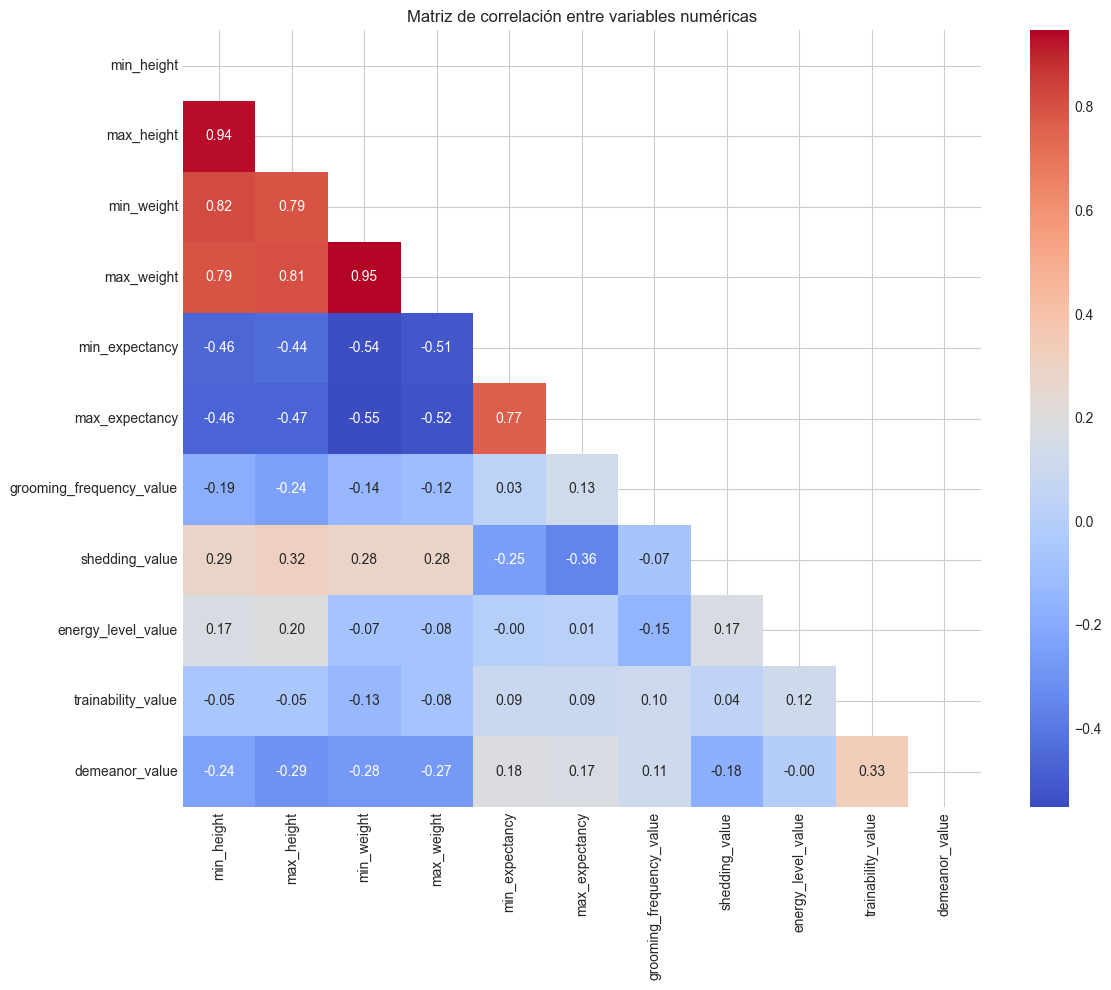

In [38]:
# Filtramos solo las columnas numéricas para la matriz de correlación
numerical_cols = df.select_dtypes(include=['number']).columns
# Creamos una matriz de correlación entre las variables numéricas
corr_matrix = df[numerical_cols].corr()

# Mostramos la matriz de correlación
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', mask=mask)
plt.title('Matriz de correlación entre variables numéricas')
plt.tight_layout()
plt.show()

## **6. Análisis de texto**

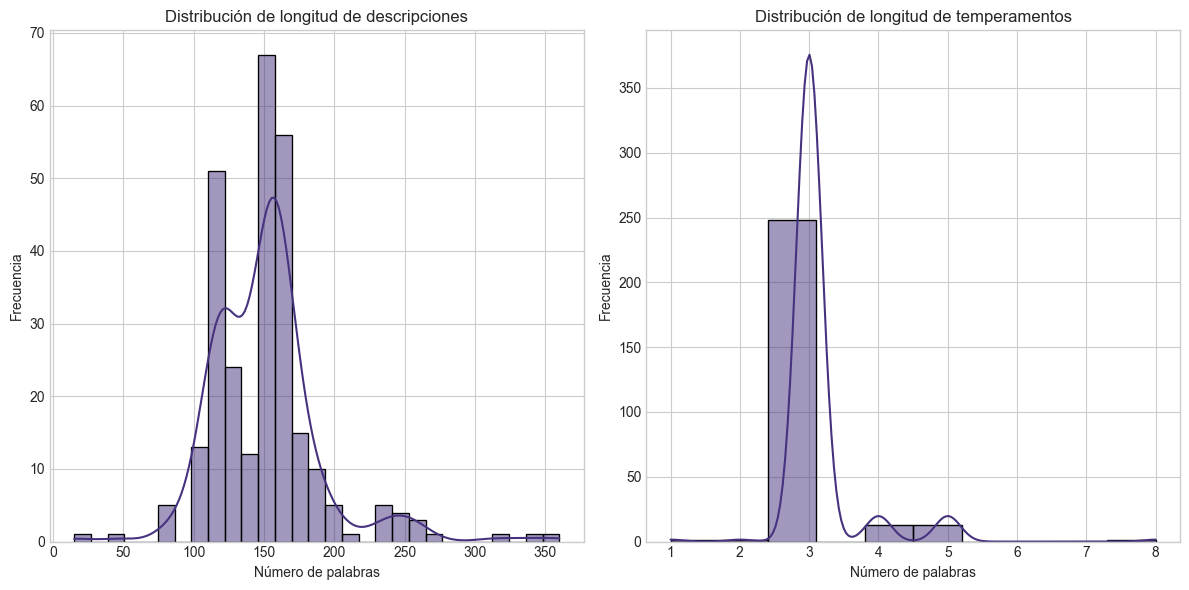

In [39]:
# Mostramos la distribución de la longitud de las descripciones y temperamentos
# para ello, calculamos la longitud de las descripciones y temperamentos
df['description_length'] = df['description'].apply(lambda x: len(str(x).split()))
df['temperament_length'] = df['temperament'].apply(lambda x: len(str(x).split()))

# Mostramos la longitud de las descripciones y temperamentos
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['description_length'], kde=True)
plt.title('Distribución de longitud de descripciones')
plt.xlabel('Número de palabras')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(df['temperament_length'], kde=True)
plt.title('Distribución de longitud de temperamentos')
plt.xlabel('Número de palabras')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

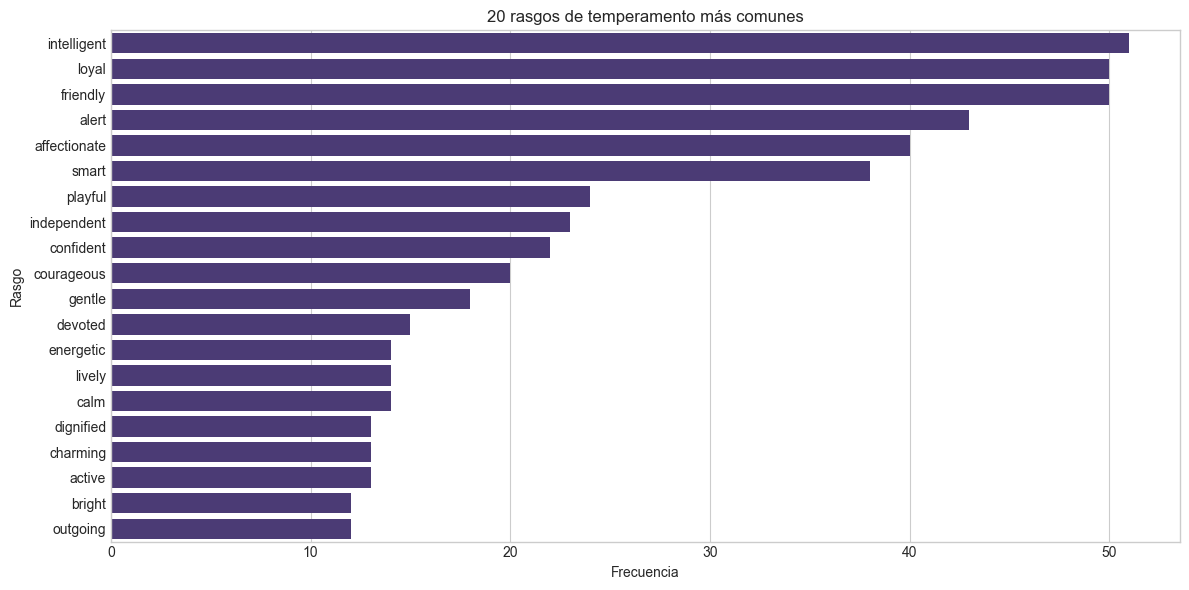

In [40]:
# Obtenemos la lista de palabras de temperamento 
from collections import Counter
import re

# Rellenamos valores nulos con una cadena vacía antes de procesar
df['temperament'] = df['temperament'].fillna('')

# Procesamos temperamentosco (vertimos a minúsculas y eliminamos comas)
all_temperament_words = ' '.join(df['temperament'].str.lower()).replace(',', '')
all_temperament_words = re.sub(r'[^\w\s]', '', all_temperament_words)
# Creamos una lista de palabras de temperamento
temperament_words = [word for word in all_temperament_words.split() if len(word) > 3]

# Contamos frecuencias
temp_counter = Counter(temperament_words)
common_traits = pd.DataFrame(temp_counter.most_common(20), columns=['Trait', 'Count'])

# Visualizamos los 20 rasgos de temperamento más comunes
plt.figure(figsize=(12, 6))
sns.barplot(x='Count', y='Trait', data=common_traits)
plt.title('20 rasgos de temperamento más comunes')
plt.xlabel('Frecuencia')
plt.ylabel('Rasgo')
plt.tight_layout()
plt.show()

## **7. Preprocesamiento de Datos**

In [41]:
from pipeline.preprocessing import preprocess_df

# Definimos columnas de texto a normalizar
text_columns = [
    "description",
    "temperament",
    "group",
    "breed",
    "grooming_frequency_category",
    "shedding_category",
    "energy_level_category",
    "trainability_category",
    "demeanor_category"
]

# Preprocesar dataframe con el pipeline de preprocesamiento que se encarga de normalizar
# y eliminar caracteres especiales, convertir a minúsculas, etc.
df_processed = preprocess_df(df, text_columns)

print("Ejemplo de datos preprocesados:")
# Mostramos las primeras filas del dataframe preprocesado
df_processed[['breed', 'group', 'temperament']].head()

Ejemplo de datos preprocesados:


,breed,group,temperament
0,affenpinscher,Toy Group,"Confident, Famously Funny, Fearless"
1,afghan_hound,Hound Group,"Dignified, Profoundly Loyal, Aristocratic"
2,airedale_terrier,Terrier Group,"Friendly, Clever, Courageous"
3,akita,Working Group,"Courageous, Dignified, Profoundly Loyal"
4,alaskan_malamute,Working Group,"Affectionate, Loyal, Playful"


## **8. Preparación de Datos para Modelos**

In [42]:
from pipeline.vectorizers import vectorize_text_tfidf, vectorize_numerical

# Vectorizamos el texto utilizando TF-IDF
# y guardamos el modelo para su uso posterior
X_text, tfidf_model = vectorize_text_tfidf(df_processed)
print(f"Dimensiones de vectores de texto: {X_text.shape}")

# Vectorizamos los datos numéricos
numerical_columns = [
    "grooming_frequency_value",
    "shedding_value",
    "energy_level_value",
    "trainability_value",
    "demeanor_value"
]

X_num, scaler = vectorize_numerical(df_processed, numerical_columns)
print(f"Dimensiones de vectores numéricos: {X_num.shape}")

Dimensiones de vectores de texto: (277, 500)
Dimensiones de vectores numéricos: (277, 5)


In [43]:
df_processed.to_csv('data/preprocessed_data.csv')
print("Conjunto de datos guardado en en 'data/preprocessed_data.csv'")

Conjunto de datos guardado en en 'data/preprocessed_data.csv'


## **9. Simulación de Matriz de Interacciones Usuario-Ítem**

In [25]:
from pipeline.simulation import simulate_user_item_matrix

# Simulamos una matriz de usuario-ítem para recomendaciones de filtrado colaborativo
# utilizando la popularidad de las razas para la simulación (razas más populares recibirán más ratings)
ratings_matrix = simulate_user_item_matrix(
    df_processed,                   # DataFrame preprocesado
    n_users=150,                    # Número de usuarios a simular
    min_ratings=50,                 # Número mínimo de ratings por usuario
    max_ratings=120,                # Número máximo de ratings por usuario
    popularity_col="popularity"     # Columna de popularidad para simular ratings
)

# Mostramos la dimensión de la matriz de ratings
print(f"Dimensiones de la matriz de ratings: {ratings_matrix.shape}")

# Mostramos las primeras filas de la matriz de ratings
ratings_matrix.iloc[:5, :5]

/Users/joseenriquerojas/Developer/Maestria/DogRecSys/pipeline/simulation.py:41: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rating_df = pd.DataFrame(index=ratings.keys(), columns=all_breeds).fillna(0)


Dimensiones de la matriz de ratings: (150, 277)


,affenpinscher,afghan_hound,airedale_terrier,akita,alaskan_malamute
User1,4,0,3,4,2
User2,3,0,0,0,0
User3,3,4,3,0,4
User4,5,4,0,0,0
User5,0,0,3,4,0


In [28]:
# Calculamos y mostramos estadísticas de la matriz de ratings

# Densidad de la matriz (proporción de ratings no nulos)
# La densidad se calcula como el número de ratings no nulos dividido por el total de posibles ratings
# (número de usuarios * número de ítems)
density = (ratings_matrix != 0).sum().sum() / (ratings_matrix.shape[0] * ratings_matrix.shape[1])

# Rating promedio (promedio de ratings no nulos)
# Se calcula como la suma de ratings no nulos dividido por el número de ratings no nulos
# Se utiliza .mean() para obtener el promedio de ratings no nulos
avg_rating = ratings_matrix[ratings_matrix > 0].mean().mean()

# Promedio de ratings por usuario (promedio de ratings no nulos por usuario)
# Se calcula como la suma de ratings no nulos por usuario dividido por el número de ratings no nulos por usuario
ratings_per_user = (ratings_matrix > 0).sum(axis=1)

# Promedio de ratings por ítem (promedio de ratings no nulos por ítem)
# Se calcula como la suma de ratings no nulos por ítem dividido por el número de ratings no nulos por ítem
ratings_per_item = (ratings_matrix > 0).sum(axis=0)

print(f"Densidad de la matriz: {density:.4f} ({density*100:.2f}%)")
print(f"Rating promedio: {avg_rating:.2f}")
print(f"Promedio de ratings por usuario: {ratings_per_user.mean():.2f}")
print(f"Promedio de ratings por raza: {ratings_per_item.mean():.2f}")
print(f"Rango de ratings por usuario: {ratings_per_user.min()} - {ratings_per_user.max()}")

Densidad de la matriz: 0.3157 (31.57%)
Rating promedio: 3.92
Promedio de ratings por usuario: 87.46
Promedio de ratings por raza: 47.36
Rango de ratings por usuario: 51 - 120


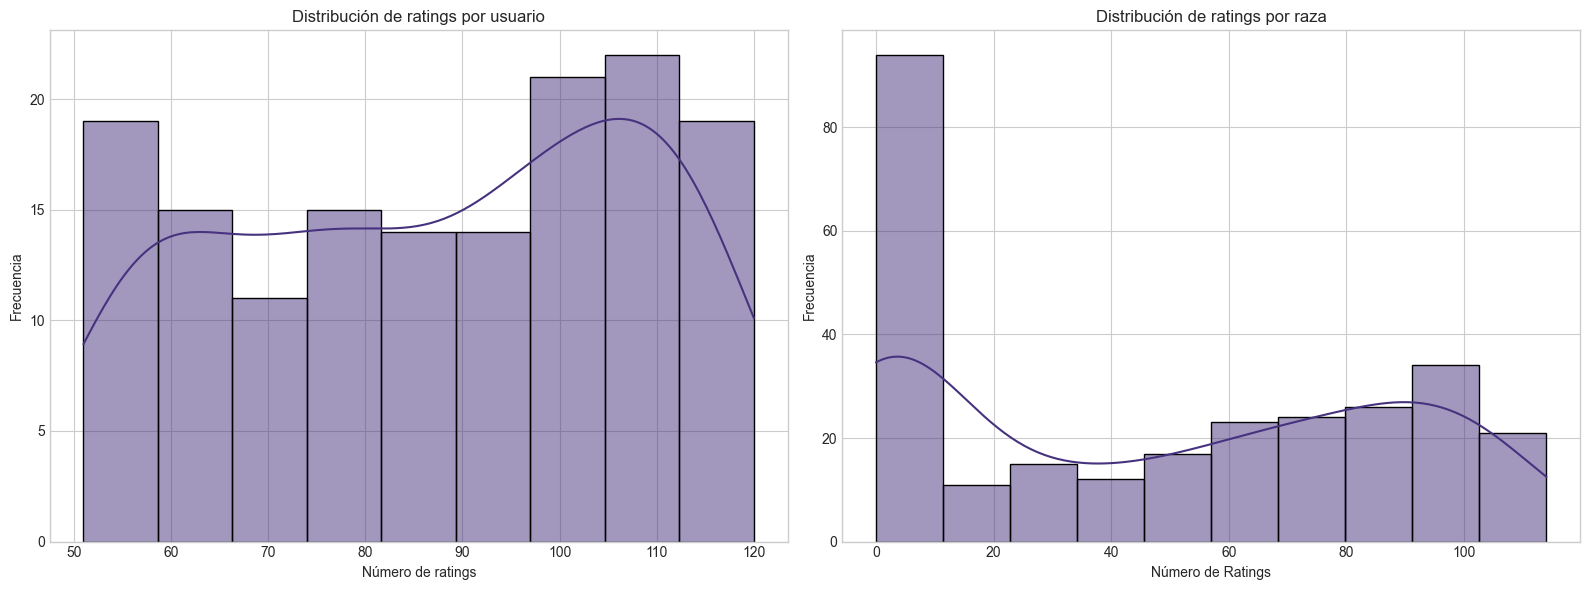

In [29]:
# Visualizamos las distribuciones
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma de ratings por usuario
sns.histplot(ratings_per_user, kde=True, ax=axes[0])
axes[0].set_title('Distribución de ratings por usuario')
axes[0].set_xlabel('Número de ratings')
axes[0].set_ylabel('Frecuencia')

# Histograma de ratings por raza
sns.histplot(ratings_per_item, kde=True, ax=axes[1])
axes[1].set_title('Distribución de ratings por raza')
axes[1].set_xlabel('Número de Ratings')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [ ]:
# Guardamos la matriz de ratings para uso en experimentación
ratings_matrix.to_csv('data/user_dog_ratings.csv')
print("Matriz de ratings guardada en 'data/user_dog_ratings.csv'")

Matriz de ratings guardada en 'data/user_dog_ratings.csv'


## **10. Resumen**

### **Principales hallazgos del análisis exploratorio:**

1. **Dataset de razas:**
   - Contamos con información detallada de múltiples razas de perros.
   - Las variables numéricas ordinales están distribuidas en escala de 1-5.
   - Hay una buena diversidad de grupos de razas.

2. **Correlaciones**
   - Razas más altas también tienden a ser más pesadas.
   - Cuanto mayor es la raza, menor su esperanza de vida promedio.
   - Nivel de energía, frecuencia de aseo y grado de muda no están muy ligados entre sí ni con tamaño.
   - Los perros más grandes tienden a mudar más pelo. Sin embargo, la frecuencia de aseo tiene correlaciones muy débiles o incluso ligeramente negativas con el tamaño y grado de muda.
   - Los perros con mejor “comportamiento/temperamento” suelen ser también más entrenables.
   - La extensión de la descripción o del texto del temperamento no depende de las características cuantitativas de la raza.


3. **Datos textuales:**
   - Las descripciones y temperamentos proporcionan información rica para análisis basado en contenido.
   - Los rasgos de temperamento más comunes incluyen "intelligent", "loyal", "friendly" y "alert".

4. **Matriz de ratings simulada:**
   - Densidad del 31.34%.
   - Distribución de ratings que imita patrones de sistemas de recomendación cotidianos (cola larga).

